dS/dt = -(0.03)(0.01)(S(t) * I(t))            S(0) = 1000             Number of iteractions multipled by portion of interactions leading to transmission multipled by -1 s it is decreasing

dI/dt = (0.03)(0.01)(S(t) * I(t)) - (0.02)(I(t))         I(0) = 1            Increases by the same rate by while the susceptible population decreases, and decreases by the same rate by white the recover population increases

dR/dt = (0.02)(I(t))             R(0) = 0          Increases by a rate of 0.02 of the current infected population


This means at t = 0

dS/dt = -0.3       dI/dt = 0.28         dR/dt =    0.02

In [10]:
from multi_var_euler_estimator import EulerEstimator

def dS_dt(t, state):
    return -0.03 * 0.01 * state['S'] * state['I']

def dI_dt(t, state):
    return (0.03 * 0.01 * state['S'] * state['I']) - (0.02 * state['I'])

def dR_dt(t, state):
    return 0.02 * state['I']

derivatives = {'S':dS_dt,  'I': dI_dt, 'R': dR_dt}
euler = EulerEstimator(derivatives)

initial_state = {'S': 1000, 'I': 1, 'R': 0}
initial_point = (0, initial_state)

points = euler.estimate_points(initial_point, step_size= 1, num_steps= 300)

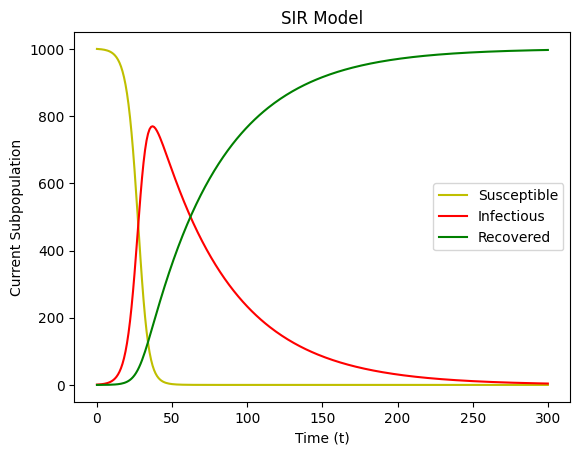

In [13]:

import matplotlib.pyplot as plt

x_points, y_points = zip(*points)

#print(x_points)
#print(y_points)

S = []
I = []
R = []

for index in range(len(y_points)):
    S.append(y_points[index]['S'])
    I.append(y_points[index]['I'])
    R.append(y_points[index]['R'])

plt.plot(x_points, S, 'y-', label = "Susceptible")
plt.plot(x_points, I, 'r-', label = "Infectious")
plt.plot(x_points, R, 'g-', label = "Recovered")

plt.xlabel('Time (t)')
plt.ylabel('Current Subpopulation')
plt.title("SIR Model")
plt.legend()
plt.show()


